<a href="https://colab.research.google.com/github/Egor-Error000/Coursework/blob/main/Progect_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# БЛОК 0

In [1]:
# ============================================================
# БЛОК 0 — Физические константы и параметры соленоида
# ============================================================
import math
# ── Фундаментальные константы (СИ) ───────────────────────────

c_light  = 299_792_458.0        # скорость света        [м/с]
e_charge = 1.602176634e-19      # элементарный заряд    [Кл]
m_e      = 9.1093837015e-31     # масса электрона       [кг]
MU0      = 4.0 * math.pi * 1e-7 # магнитная постоянная  [Тл·м/А]

# ── Производные единицы энергии ───────────────────────────────

eV  = e_charge     # 1 эВ  в джоулях
keV = 1e3 * eV
MeV = 1e6 * eV
GeV = 1e9 * eV

# ── Параметры соленоида ───────────────────────────────────────

R = 0.10   # [м]  средний радиус обмотки
a = 0.02   # [м]  полутолщина обмотки  →  R_in = R-a,  R_out = R+a
b = 0.20   # [м]  полудлина соленоида  →  length = 2b

J    = 1e3       # [А/см²]  плотность тока обмотки
J_SI = J * 1e4   # [А/м²]   то же в СИ  (1 А/см² = 10⁴ А/м²)
                 # используется в SimpleFieldGrid (Блок II)

# БЛОК I

In [2]:
# ============================================================
# БЛОК I — Импорты и датаклассы
# ============================================================
#
# Изменения относительно оригинала:
#
#   УДАЛЕНО:
#     - drive.mount('/content/drive')  — работаем через GitHub
#     - дублирующий import numpy as np
#     - from typing import Tuple, List, Callable  — нигде не используется
#     - float32, int32 из numba  — не используются напрямую
#     - FieldGridConfig  — специфичен для FNT-сетки, заменён SimpleFieldGrid
#     - BeamDiagnosticsData  — не использовался нигде в коде
#       (вместо него работает класс BeamDiagnostics из Блока V)
#
#   ОСТАВЛЕНО:
#     + SolenoidParams        — используется в Блоках II, VI
#     + BeamPhysicalParams    — используется в Блоках IV, VI
#     + BeamNumericalParams   — используется в Блоках V, VI
#     + DimensionlessScaling  — используется в ScalingTransform (Блок IV)
#
#   ДОБАВЛЕНО:
#     + sys.path для импорта .py модулей из репозитория GitHub
#
# ============================================================

import sys
import numpy as np
import math
import matplotlib.pyplot as plt
from dataclasses import dataclass
from abc import ABC, abstractmethod
from numba import cuda

# Путь к .py модулям проекта (клонированный репозиторий)
# !git clone https://github.com/your-username/your-repo.git  ← выполнить один раз
# sys.path.insert(0, '/content/your-repo')   # ← заменить на реальное имя репо


# ── Датаклассы ────────────────────────────────────────────────

@dataclass
class SolenoidParams:
    """Геометрия и масштаб одного соленоида."""
    center:  np.ndarray   # (3,) [м]  центр (x, y, z)
    const:   float        # безразмерный коэффициент масштаба поля
    length:  float        # полная длина [м]
    R_inner: float        # внутренний радиус [м]
    R_outer: float        # внешний радиус [м]


@dataclass
class BeamPhysicalParams:
    """Физические параметры частиц пучка (все в СИ)."""
    mass:           float   # [кг]
    charge:         float   # [Кл]
    c:              float   # [м/с]
    kinetic_energy: float   # [Дж]  (не эВ!)


@dataclass
class BeamNumericalParams:
    """
    Параметры численного интегрирования.

    t_start, t_end задаются в физических единицах [с].
    Безразмерный шаг dt̃ вычисляется автоматически в BeamTracerCUDA:
        dt̃ = (t_end - t_start) / (n_steps · T0)

    Пример:
        BeamNumericalParams(t_start=0.0, t_end=15e-9,
                            n_steps=16_000, threads_per_block=128)
    """
    t_start:           float   # [с]  начало интегрирования (обычно 0)
    t_end:             float   # [с]  конец  интегрирования
    n_steps:           int     # число шагов
    threads_per_block: int     # потоков на блок CUDA


@dataclass
class DimensionlessScaling:
    """
    Масштабы для обезразмеривания.
    Заполняется фабричным методом ScalingTransform.from_physical_problem().
    """
    length:   float   # L0 [м]
    time:     float   # T0 [с]
    momentum: float   # P0 [кг·м/с]
    field:    float   # B0 [Тл]

# БЛОК II

In [3]:
# ── Интерфейс ─────────────────────────────────────────────────
from abc import ABC, abstractmethod
class FieldGridBase(ABC):
    """Базовый класс для любой сетки поля. Все значения в [м] и [Тл]."""

    @property
    @abstractmethod
    def r_min_phys(self) -> float: ...

    @property
    @abstractmethod
    def r_max_phys(self) -> float: ...

    @property
    @abstractmethod
    def z_min_phys(self) -> float: ...

    @property
    @abstractmethod
    def z_max_phys(self) -> float: ...

    @property
    @abstractmethod
    def Nr(self) -> int: ...

    @property
    @abstractmethod
    def Nz(self) -> int: ...

    @property
    @abstractmethod
    def Br_host(self) -> np.ndarray: ...

    @property
    @abstractmethod
    def Bz_host(self) -> np.ndarray: ...

In [4]:
# ============================================================
# БЛОК II — FNTFieldGrid
# ============================================================

class FNTFieldGrid(FieldGridBase):
    """
    Неравномерная (tanh-растянутая) сетка магнитного поля одного соленоида.

    Хранит ПОЛОВИННУЮ сетку по z: z ∈ [0, b] (только z ≥ 0 относительно
    центра соленоида). Продолжение на z < 0 выполняется в CUDA-ядре через
    симметрию/антисимметрию:
        Bz(r, -Δz) = +Bz(r, +Δz)   — чётная
        Br(r, -Δz) = -Br(r, +Δz)   — нечётная

    При двух и более одинаковых соленоидах используется ОДНА эта сетка.
    Суперпозиция поля выполняется в CUDA-ядре.

    Parameters
    ----------
    r_grid   : (Nr,)      float — физическая ось r [м], r ∈ [0, r_max]
    z_half   : (Nz_h,)    float — физическая ось z [м], z ∈ [0, b]
    Br_half  : (Nr, Nz_h) float — радиальная компонента [Тл]
    Bz_half  : (Nr, Nz_h) float — осевая компонента    [Тл]
    beta_r   : float            — параметр tanh-растяжки по r
    alpha_z  : float            — параметр tanh-растяжки по z
    """

    def __init__(self, r_grid, z_half, Br_half, Bz_half, beta_r, alpha_z):
        self._r_grid  = np.asarray(r_grid,  dtype=np.float32)
        self._z_half  = np.asarray(z_half,  dtype=np.float32)
        self._Br_half = np.asarray(Br_half, dtype=np.float32)
        self._Bz_half = np.asarray(Bz_half, dtype=np.float32)

        self._beta_r  = float(beta_r)
        self._alpha_z = float(alpha_z)

        Nr, Nz_h = self._Br_half.shape
        assert self._r_grid.shape[0] == Nr,   "r_grid не совпадает с Br_half по r"
        assert self._z_half.shape[0] == Nz_h, "z_half не совпадает с Br_half по z"

        self._Nr   = Nr
        self._Nz_h = Nz_h

        self._r_min_phys = float(self._r_grid[0])    # = 0
        self._r_max_phys = float(self._r_grid[-1])
        self._z_max_half = float(self._z_half[-1])   # = b

        print(f"FNTFieldGrid создана:")
        print(f"  Nr = {Nr},  Nz_half = {Nz_h}")
        print(f"  r  ∈ [{self._r_min_phys:.4f}, {self._r_max_phys:.4f}] м")
        print(f"  z  ∈ [0, {self._z_max_half:.4f}] м  (половинная)")
        print(f"  beta_r  = {self._beta_r},  alpha_z = {self._alpha_z}")
        print(f"  Bz_max  = {self._Bz_half.max()*1e3:.2f} мТл")
        print(f"  Br_max  = {self._Br_half.max()*1e3:.2f} мТл")

    # ── FieldGridBase interface ────────────────────────────────────────────

    @property
    def r_min_phys(self): return self._r_min_phys

    @property
    def r_max_phys(self): return self._r_max_phys

    @property
    def z_min_phys(self): return -self._z_max_half

    @property
    def z_max_phys(self): return  self._z_max_half

    @property
    def Nr(self): return self._Nr

    @property
    def Nz(self): return self._Nz_h

    @property
    def Br_host(self): return self._Br_half

    @property
    def Bz_host(self): return self._Bz_half

    # ── Специфичные свойства FNT ──────────────────────────────────────────

    @property
    def beta_r(self):          return self._beta_r

    @property
    def alpha_z(self):         return self._alpha_z

    @property
    def z_max_half_phys(self): return self._z_max_half

    # ── GPU upload ────────────────────────────────────────────────────────

    def upload_to_gpu(self):
        """Копирует сетку на GPU. Вызывать один раз перед запуском трекера."""
        self.Br_d = cuda.to_device(self._Br_half)
        self.Bz_d = cuda.to_device(self._Bz_half)
        print("FNTFieldGrid: данные скопированы на GPU.")

    # ── Проверка физических свойств поля ─────────────────────────────────

    def check_symmetry(self, rtol=1e-3):
        """
        Проверяет физические свойства половинной сетки без экстраполяции.

        Три независимых теста, каждый работает только в области z ≥ 0:

        1. Br(r=0, z) = 0  — ось симметрии: на оси радиальное поле равно нулю.

        2. Br(r, z=0) = 0  — граница симметрии: Br нечётна по z,
           значит при z=0 она обязана обращаться в ноль.

        3. ∇·B = 0  — закон Гаусса в цилиндрических координатах:
           (1/r)·∂(r·Br)/∂r + ∂Bz/∂z = 0
           Проверяется через конечные разности во внутренних точках.
        """
        ok = True

        # ── Тест 1: Br на оси (первая строка по r) ────────────────────────
        Br_axis     = self._Br_half[0, :]                        # (Nz_h,)
        err_axis    = np.max(np.abs(Br_axis)) / (np.max(np.abs(self._Br_half)) + 1e-30)
        status_axis = "✓" if err_axis < rtol else "✗  ОШИБКА"
        print(f"Тест 1  Br(r=0):   max|Br_axis| / max|Br| = {err_axis:.2e}  {status_axis}")
        if err_axis >= rtol:
            ok = False

        # ── Тест 2: Br при z=0 (первый столбец по z) ──────────────────────
        Br_z0     = self._Br_half[:, 0]                          # (Nr,)
        err_z0    = np.max(np.abs(Br_z0)) / (np.max(np.abs(self._Br_half)) + 1e-30)
        status_z0 = "✓" if err_z0 < rtol else "✗  ОШИБКА"
        print(f"Тест 2  Br(z=0):   max|Br_z0|  / max|Br| = {err_z0:.2e}  {status_z0}")
        if err_z0 >= rtol:
            ok = False

        # ── Тест 3: ∇·B = 0 через конечные разности ──────────────────────
        # Работаем на внутренних узлах (1 .. Nr-2) × (1 .. Nz_h-2),
        # чтобы избежать граничных эффектов.
        r = self._r_grid[1:-1, np.newaxis]           # (Nr-2, 1)
        dr = (self._r_grid[2:]  - self._r_grid[:-2]) / 2.0   # центральная разность
        dz = (self._z_half[2:]  - self._z_half[:-2]) / 2.0

        Br_inner = self._Br_half[1:-1, 1:-1]         # (Nr-2, Nz_h-2)
        dBrr_dr  = (self._Br_half[2:,  1:-1] * self._r_grid[2:,  np.newaxis]
                  - self._Br_half[:-2, 1:-1] * self._r_grid[:-2, np.newaxis]
                   ) / (2.0 * dr[:, np.newaxis] * r)

        dBz_dz   = (self._Bz_half[1:-1, 2:]
                  - self._Bz_half[1:-1, :-2]
                   ) / (2.0 * dz[np.newaxis, :])

        divB     = dBrr_dr + dBz_dz
        divB_rel = np.max(np.abs(divB)) / (np.max(np.abs(self._Bz_half)) + 1e-30)
        status_div = "✓" if divB_rel < rtol else "✗  ОШИБКА"
        print(f"Тест 3  ∇·B=0:     max|∇·B| / max|Bz|    = {divB_rel:.2e}  {status_div}")
        if divB_rel >= rtol:
            ok = False

        print("  Все тесты пройдены ✓" if ok else "  Есть нарушения — проверьте исходные данные.")

    # ── Визуализация ──────────────────────────────────────────────────────

    def plot(self, figsize=(13, 9)):
        """
        2×2 подграфика:
          Строка 1 — поля в физических координатах (r, z) [см]
          Строка 2 — те же поля в индексном пространстве (i, j)
                     наглядно показывает сгущение узлов tanh-сетки
        """
        from matplotlib.colors import SymLogNorm

        r_cm = self._r_grid * 1e2    # физические оси
        z_cm = self._z_half * 1e2

        ir = np.arange(self._Nr)      # индексные оси
        iz = np.arange(self._Nz_h)

        fields = [self._Bz_half * 1e3, self._Br_half * 1e3]
        titles_phys  = ["Bz [мТл]  —  физ. координаты",
                        "Br [мТл]  —  физ. координаты"]
        titles_index = ["Bz [мТл]  —  индексное пространство (i,j)",
                        "Br [мТл]  —  индексное пространство (i,j)"]

        fig, axes = plt.subplots(2, 2, figsize=figsize)

        for col, field in enumerate(fields):

            vmax = np.max(np.abs(field))
            norm = SymLogNorm(linthresh=0.01 * vmax + 1e-10,
                              vmin=-vmax, vmax=vmax)

            # ── Строка 0: физические координаты ──────────────────────────
            Z_phys, R_phys = np.meshgrid(z_cm, r_cm)
            cf0 = axes[0, col].pcolormesh(Z_phys, R_phys, field,
                                          cmap='RdBu_r', norm=norm,
                                          shading='auto')
            plt.colorbar(cf0, ax=axes[0, col])
            axes[0, col].set_xlabel('z [см]')
            axes[0, col].set_ylabel('r [см]')
            axes[0, col].set_title(titles_phys[col])

            # ── Строка 1: индексное пространство ─────────────────────────
            IZ, IR = np.meshgrid(iz, ir)
            cf1 = axes[1, col].pcolormesh(IZ, IR, field,
                                          cmap='RdBu_r', norm=norm,
                                          shading='auto')
            plt.colorbar(cf1, ax=axes[1, col])
            axes[1, col].set_xlabel('индекс j  (ось z)')
            axes[1, col].set_ylabel('индекс i  (ось r)')
            axes[1, col].set_title(titles_index[col])

        plt.suptitle("FNT-сетка: половинное поле (z ≥ 0 от центра соленоида)")
        plt.tight_layout()
        plt.show()

# БЛОК III

In [5]:
# ============================================================
# БЛОК III — Геометрия и визуализация
# ============================================================
#
# Содержит:
#   1. cartesian_to_cylindrical  — для диагностики геометрии пучка
#   2. plot_solenoid_system      — визуализация конфигурации системы
#
# ============================================================


def cartesian_to_cylindrical(points: np.ndarray):
    """
    Декартовы (x, y, z) → цилиндрические компоненты.

    Используется в BeamDiagnostics для вычисления r и phi частиц.
    Деление на ноль при r=0 исключено через маску.

    Parameters
    ----------
    points : (N, 3) [м]

    Returns
    -------
    r       : (N,)  радиальная координата √(x²+y²) [м]
    z       : (N,)  осевая координата [м]
    cos_phi : (N,)  cos φ = x / r  (0 при r=0)
    sin_phi : (N,)  sin φ = y / r  (0 при r=0)
    """
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    r     = np.sqrt(x * x + y * y)
    mask  = r > 0.0
    inv_r = np.where(mask, 1.0 / np.where(mask, r, 1.0), 0.0)

    return r, z, x * inv_r, y * inv_r


def plot_solenoid_system(solenoids, z_start=0.0, r_beam=1e-3):
    """
    Поперечное сечение системы соленоидов в плоскости (z, x).

    Parameters
    ----------
    solenoids : list[SolenoidParams]
    z_start   : float  — осевая позиция старта пучка [м]
    r_beam    : float  — радиус пучка для отображения [м]
    """
    fig, ax = plt.subplots(figsize=(10, 4))

    for k, sol in enumerate(solenoids):
        z_c = sol.center[2]
        z1  = z_c - sol.length / 2
        z2  = z_c + sol.length / 2

        # Обмотка
        ax.fill_betweenx(
            [-sol.R_outer, sol.R_outer], z1, z2,
            color='tab:blue', alpha=0.25,
            label=f'Соленоид {k+1}' if k == 0 else f'Соленоид {k+1}',
        )
        # Внутренний канал (вырез)
        ax.fill_betweenx(
            [-sol.R_inner, sol.R_inner], z1, z2,
            color='white',
        )
        # Осевая метка центра соленоида
        ax.plot([z_c, z_c], [-sol.R_outer, sol.R_outer],
                'k--', alpha=0.4, linewidth=0.8)
        ax.text(z_c, sol.R_outer * 1.05, f'S{k+1}',
                ha='center', va='bottom', fontsize=8, color='tab:blue')

    # Стартовое сечение пучка
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(
        z_start + np.zeros_like(theta),
        r_beam  * np.cos(theta),
        'r', linewidth=1.5, label=f'Старт пучка  r={r_beam*1e3:.1f} мм',
    )

    ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
    ax.set_xlabel('z [м]')
    ax.set_ylabel('x [м]')
    ax.set_title('Система соленоидов — сечение xz')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

# БЛОК IV

In [6]:
# ============================================================
# БЛОК IV — Масштабирование, диагностика, адаптер сетки
# ============================================================


class ScalingTransform:
    """
    Масштабирование между физическими и безразмерными переменными.

    Масштабы выбираются из начальных параметров частицы:

        P0 = m·c·√(γ₀² - 1)      — начальный импульс [кг·м/с]
        T0 = L0 / c               — характерное время [с]
        B0 = P0 / (|q|·L0)       — характерное поле [Тл]

    Безразмерные переменные:
        x̃ = x / L0,   p̃ = p / P0,   t̃ = t / T0,   B̃ = B / B0

    В безразмерных переменных уравнения движения:
        γ     = √(1 + |p̃|²)
        ṽ     = p̃ / γ
        dp̃/dt̃ = ṽ × B̃
        dx̃/dt̃ = ṽ
    """

    def __init__(self, scaling: 'DimensionlessScaling', phys: 'BeamPhysicalParams'):
        self.L0 = scaling.length      # [м]
        self.T0 = scaling.time        # [с]
        self.P0 = scaling.momentum    # [кг·м/с]
        self.B0 = scaling.field       # [Тл]

        self.m = phys.mass            # [кг]
        self.q = phys.charge          # [Кл]
        self.c = phys.c               # [м/с]

        # Коэффициент для пересчёта безразмерного p̃ → физический γ:
        #   γ = √(1 + |p̃·P0/(mc)|²) = √(1 + |p̃|²·α²)
        #   α = P0 / (m·c) = √(γ₀² − 1)
        self._alpha2 = (self.P0 / (self.m * self.c)) ** 2

    # ── физические → безразмерные ─────────────────────────────────────────

    def to_dimless_x(self, x): return x / self.L0
    def to_dimless_p(self, p): return p / self.P0
    def to_dimless_t(self, t): return t / self.T0

    # ── безразмерные → физические ─────────────────────────────────────────

    def from_dimless_x(self, x): return x * self.L0
    def from_dimless_p(self, p): return p * self.P0
    def from_dimless_t(self, t): return t * self.T0

    # ── релятивистские вспомогательные ────────────────────────────────────

    def gamma_phys(self, p_dimless: np.ndarray) -> np.ndarray:
        """
        Физический γ-фактор из безразмерного импульса p̃.

            γ = √(1 + |p̃·P0/(mc)|²) = √(1 + |p̃|²·α²)

        При p̃=1 (начальный импульс) возвращает γ₀ — проверяемо.
        """
        return np.sqrt(1.0 + np.sum(p_dimless ** 2, axis=-1) * self._alpha2)

    def velocity(self, p_dimless: np.ndarray) -> np.ndarray:
        """ṽ = p̃ / γ̃  где γ̃ = √(1 + |p̃|²)  — безразмерная скорость."""
        gamma_tilde = np.sqrt(1.0 + np.sum(p_dimless ** 2, axis=-1))
        return p_dimless / gamma_tilde[..., None]

    def energy_to_momentum(self, Ek: float) -> float:
        """
        Кинетическая энергия → безразмерный импульс p̃ = p / P0.

            γ  = 1 + Eₖ / (mc²)
            p  = mc · √(γ² - 1)   [кг·м/с]
            p̃  = p / P0

        Parameters
        ----------
        Ek : float  кинетическая энергия [Дж]

        Returns
        -------
        p_dimless : float  (используется для инициализации p0)
        """
        gamma = 1.0 + Ek / (self.m * self.c ** 2)
        p_si  = self.m * self.c * np.sqrt(gamma ** 2 - 1.0)
        return p_si / self.P0

    # ── фабричный метод ───────────────────────────────────────────────────

    @classmethod
    def from_physical_problem(cls, phys: 'BeamPhysicalParams', L0: float):
        """
        Создать ScalingTransform из физических параметров частицы.

            dp/dt = q·v×B  →  dp̃/dt̃ = ṽ × B̃
            ⟹  B0 = P0 / (|q|·L0)

        Parameters
        ----------
        phys : BeamPhysicalParams
        L0   : float  характерная длина [м]
        """
        gamma0 = 1.0 + phys.kinetic_energy / (phys.mass * phys.c ** 2)
        P0     = phys.mass * phys.c * np.sqrt(gamma0 ** 2 - 1.0)
        T0     = L0 / phys.c
        B0     = P0 / (abs(phys.charge) * L0)

        scaling = DimensionlessScaling(
            length   = L0,
            time     = T0,
            momentum = P0,
            field    = B0,
        )
        obj = cls(scaling=scaling, phys=phys)

        print("ScalingTransform создан:")
        print(f"  γ₀   = {gamma0:.6f}")
        print(f"  L0   = {L0:.3e} м")
        print(f"  P0   = {P0:.3e} кг·м/с")
        print(f"  T0   = {T0:.3e} с  ({T0*1e9:.4f} нс)")
        print(f"  B0   = {B0:.3e} Тл")

        return obj


# ─────────────────────────────────────────────────────────────────────────────


class BeamDiagnostics:
    """
    Усреднённые характеристики пучка, записываемые на каждом шаге.

    record() принимает безразмерные x̃, p̃, B̃.
    Физический γ восстанавливается через scaling._alpha2.
    """

    def __init__(self):
        self.steps         = []
        self.mean_gamma    = []   # физический γ
        self.mean_p        = []   # [кг·м/с]
        self.mean_B        = []   # [Тл]
        self.mean_F        = []   # безразм.  |ṽ × B̃|
        self.mean_z        = []   # [м]
        self.rms_r         = []   # [м]
        self.frac_in_field = []

    def record(self, step: int, x: np.ndarray, p: np.ndarray,
               B_dimless: np.ndarray, scaling: 'ScalingTransform'):
        """
        Parameters
        ----------
        step      : int
        x         : (N, 3) float — безразмерные координаты x̃
        p         : (N, 3) float — безразмерные импульсы   p̃
        B_dimless : (N, 3) float — безразмерное поле       B̃
        scaling   : ScalingTransform
        """
        p2 = np.sum(p ** 2, axis=1)

        # ── Физический γ: sqrt(1 + |p̃|²·α²),  α² = (P0/mc)² ──────────────
        gamma = np.sqrt(1.0 + p2 * scaling._alpha2)

        # ── Безразмерная скорость ṽ = p̃ / γ̃,  γ̃ = sqrt(1 + |p̃|²) ─────────
        gamma_tilde = np.sqrt(1.0 + p2)
        v     = p / gamma_tilde[:, None]

        B_abs = np.linalg.norm(B_dimless, axis=1)
        F_abs = np.linalg.norm(np.cross(v, B_dimless), axis=1)

        x_phys = scaling.from_dimless_x(x)
        r = np.sqrt(x_phys[:, 0] ** 2 + x_phys[:, 1] ** 2)

        self.steps.append(step)
        self.mean_gamma.append(float(gamma.mean()))
        self.mean_p.append(float(np.sqrt(p2).mean() * scaling.P0))
        self.mean_B.append(float(B_abs.mean() * scaling.B0))
        self.mean_F.append(float(F_abs.mean()))
        self.mean_z.append(float(x_phys[:, 2].mean()))
        self.rms_r.append(float(np.sqrt(np.mean(r ** 2))))
        self.frac_in_field.append(float(np.mean(B_abs > 0.0)))


# ─────────────────────────────────────────────────────────────────────────────


class DimensionlessGridAdapter:
    """
    Переводит FNTFieldGrid (или SimpleFieldGrid) в безразмерные единицы
    и загружает данные на GPU.
    """

    def __init__(self, field_grid, scaling: ScalingTransform,
                 solenoids=None):
        L0 = scaling.L0
        B0 = scaling.B0

        self.is_fnt = isinstance(field_grid, FNTFieldGrid)
        self.Nr     = field_grid.Nr
        self.Nz     = field_grid.Nz

        Br_norm = (field_grid.Br_host / B0).astype(np.float32)
        Bz_norm = (field_grid.Bz_host / B0).astype(np.float32)
        self.Br_d = cuda.to_device(Br_norm)
        self.Bz_d = cuda.to_device(Bz_norm)

        if self.is_fnt:
            fg = field_grid

            self.r_min      = np.float32(fg.r_min_phys      / L0)
            self.r_max      = np.float32(fg.r_max_phys      / L0)
            self.z_max_half = np.float32(fg.z_max_half_phys / L0)
            self.beta_r     = np.float32(fg.beta_r)
            self.alpha_z    = np.float32(fg.alpha_z)

            if solenoids is None:
                raise ValueError("Для FNTFieldGrid необходимо передать solenoids=...")
            z_centers = np.array([sol.center[2] / L0 for sol in solenoids],
                                 dtype=np.float32)
            self.sol_centers_d = cuda.to_device(z_centers)
            self.n_solenoids   = len(solenoids)

            self.z_min = np.float32(-self.z_max_half)
            self.z_max = np.float32( self.z_max_half)

            print("DimensionlessGridAdapter (FNT):")
            print(f"  r̃ ∈ [{self.r_min:.3f}, {self.r_max:.3f}]")
            print(f"  z̃_half ∈ [0, {self.z_max_half:.3f}]")
            print(f"  B0 = {B0:.3e} Тл")
            print(f"  Соленоиды ẑ_c = {z_centers}")

        else:
            fg = field_grid

            self.r_min = np.float32(fg.r_min_phys / L0)
            self.r_max = np.float32(fg.r_max_phys / L0)
            self.z_min = np.float32(fg.z_min_phys / L0)
            self.z_max = np.float32(fg.z_max_phys / L0)

            self.beta_r        = None
            self.alpha_z       = None
            self.z_max_half    = None
            self.sol_centers_d = None
            self.n_solenoids   = 0

            print("DimensionlessGridAdapter (Simple):")
            print(f"  r̃ ∈ [{self.r_min:.3f}, {self.r_max:.3f}]")
            print(f"  z̃ ∈ [{self.z_min:.3f}, {self.z_max:.3f}]")

# БЛОК V

In [7]:
# @title @timed_run
import time
from functools import wraps

def timed_run(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start_wall = time.perf_counter()

        start_gpu = cuda.event()
        stop_gpu  = cuda.event()
        start_gpu.record()

        result = func(*args, **kwargs)

        stop_gpu.record()
        stop_gpu.synchronize()

        gpu_time_ms = cuda.event_elapsed_time(start_gpu, stop_gpu)
        wall_time = time.perf_counter() - start_wall

        print("\n=== RUN TIME ===")
        print(f"GPU time  : {gpu_time_ms/1000:.4f} s")
        print(f"Wall time : {wall_time:.4f} s")
        print("================\n")

        return result
    return wrapper

In [8]:
# ============================================================
# БЛОК V — CUDA device-функции и трекировщик
# ============================================================

from tqdm.notebook import tqdm


# ── Вспомогательные device-функции ───────────────────────────────────────────

@cuda.jit(device=True, inline=True)
def _phys_to_index(coord, c_min, c_max, beta, N):
    """Физическая координата → дробный индекс на tanh-сетке."""
    if coord <= c_min:
        return 0.0
    if coord >= c_max:
        return float(N - 1)
    s   = (coord - c_min) / (c_max - c_min)
    arg = s * math.tanh(beta)
    if arg >=  1.0: arg =  1.0 - 1e-6
    if arg <= -1.0: arg = -1.0 + 1e-6
    u = 0.5 * math.log((1.0 + arg) / (1.0 - arg)) / beta
    return u * float(N - 1)


@cuda.jit(device=True, inline=True)
def _catmull_rom_weights(t):
    """Веса кубического сплайна Catmull-Rom для дробного смещения t ∈ [0,1]."""
    t2 = t * t
    t3 = t2 * t
    w0 = -0.5*t3 + 1.0*t2 - 0.5*t
    w1 =  1.5*t3 - 2.5*t2         + 1.0
    w2 = -1.5*t3 + 2.0*t2 + 0.5*t
    w3 =  0.5*t3 - 0.5*t2
    return w0, w1, w2, w3


@cuda.jit(device=True, inline=True)
def _bicubic_interp(field, fr, fz, Nr, Nz):
    """
    Бикубическая интерполяция Catmull-Rom на сетке field[Nr, Nz].
    Вблизи границ автоматически деградирует до билинейной.
    """
    ir = int(fr)
    iz = int(fz)

    # ── Граничная зона: билинейная интерполяция ───────────────────────────
    if ir < 1 or ir >= Nr - 2 or iz < 1 or iz >= Nz - 2:
        ir_c = min(max(ir, 0), Nr - 2)
        iz_c = min(max(iz, 0), Nz - 2)
        tr = min(max(fr - float(ir_c), 0.0), 1.0)
        tz = min(max(fz - float(iz_c), 0.0), 1.0)
        return (field[ir_c,     iz_c    ] * (1.0 - tr) * (1.0 - tz)
              + field[ir_c + 1, iz_c    ] *        tr  * (1.0 - tz)
              + field[ir_c,     iz_c + 1] * (1.0 - tr) *        tz
              + field[ir_c + 1, iz_c + 1] *        tr  *        tz)

    # ── Внутренняя область: Catmull-Rom ───────────────────────────────────
    tr = fr - float(ir)
    tz = fz - float(iz)
    wr0, wr1, wr2, wr3 = _catmull_rom_weights(tr)
    wz0, wz1, wz2, wz3 = _catmull_rom_weights(tz)

    result = 0.0
    for di, wr in enumerate((wr0, wr1, wr2, wr3)):
        ri  = ir - 1 + di
        row = (field[ri, iz - 1] * wz0
             + field[ri, iz    ] * wz1
             + field[ri, iz + 1] * wz2
             + field[ri, iz + 2] * wz3)
        result += wr * row
    return result


@cuda.jit(device=True, inline=True)
def _field_one_solenoid(Br_grid, Bz_grid,
                        r_t, dz,
                        r_min, r_max, z_max_half,
                        beta_r, alpha_z,
                        Nr, Nz_half):
    """
    Поле одного соленоида в точке (r_t, dz) в безразмерных единицах.
    Симметрия учитывается аналитически: Bz чётна, Br нечётна по dz.

    Returns
    -------
    Br_cyl, Bz_cyl : float32
    """
    # На оси: Br = 0 по определению
    if r_t <= 0.0:
        fz = _phys_to_index(math.fabs(dz), 0.0, z_max_half, alpha_z, Nz_half)
        return 0.0, _bicubic_interp(Bz_grid, 0.0, fz, Nr, Nz_half)

    # За пределами сетки: поле = 0
    if r_t >= r_max or math.fabs(dz) >= z_max_half:
        return 0.0, 0.0

    sign_Br = 1.0 if dz >= 0.0 else -1.0
    fr = _phys_to_index(r_t,           r_min, r_max,      beta_r,  Nr)
    fz = _phys_to_index(math.fabs(dz), 0.0,   z_max_half, alpha_z, Nz_half)

    return (_bicubic_interp(Br_grid, fr, fz, Nr, Nz_half) * sign_Br,
            _bicubic_interp(Bz_grid, fr, fz, Nr, Nz_half))


# ── CUDA-ядро: один шаг методом Бориса ───────────────────────────────────────
#
#  Алгоритм Бориса (релятивистский):
#      γ⁻  = √(1 + |p̃|²)
#      t   = B̃·(dt̃/2)/γ⁻       ← вектор поворота
#      p'  = p̃ + p̃×t             ← первичный поворот
#      s   = 2t/(1+|t|²)          ← нормированный вектор
#      p̃⁺  = p̃ + p'×s             ← финальный поворот  →  |p̃⁺|=|p̃| точно
#      x̃⁺  = x̃ + (p̃⁺/γ⁺)·dt̃     ← шаг координаты

@cuda.jit
def beam_step_kernel_fnt(
    x,            # (N, 3) float32  [in/out]  безразмерные координаты
    p,            # (N, 3) float32  [in/out]  безразмерные импульсы
    Br_grid,      # (Nr, Nz_half) float32
    Bz_grid,      # (Nr, Nz_half) float32
    sol_centers,  # (n_sols,) float32         безразм. центры соленоидов
    r_min, r_max, z_max_half,
    beta_r, alpha_z,
    Nr, Nz_half,
    dt,
    Bx_out, By_out, Bz_out,  # (N,) float32  [out]  поле для диагностики
):
    i = cuda.grid(1)
    if i >= x.shape[0]:
        return

    x_t = x[i, 0];  y_t = x[i, 1];  z_t = x[i, 2]
    r_t = math.sqrt(x_t*x_t + y_t*y_t)

    # ── Суперпозиция поля всех соленоидов ────────────────────────────────
    Br_cyl = 0.0;  Bz_cyl = 0.0
    for k in range(sol_centers.shape[0]):
        Br_k, Bz_k = _field_one_solenoid(
            Br_grid, Bz_grid,
            r_t, z_t - sol_centers[k],
            r_min, r_max, z_max_half,
            beta_r, alpha_z, Nr, Nz_half,
        )
        Br_cyl += Br_k
        Bz_cyl += Bz_k

    # ── Цилиндрические → декартовы ───────────────────────────────────────
    if r_t > 0.0:
        cos_phi = x_t / r_t;  sin_phi = y_t / r_t
    else:
        cos_phi = 1.0;        sin_phi = 0.0

    Bx = Br_cyl * cos_phi
    By = Br_cyl * sin_phi
    Bz = Bz_cyl

    Bx_out[i] = Bx;  By_out[i] = By;  Bz_out[i] = Bz

    # ── Метод Бориса ─────────────────────────────────────────────────────
    px = p[i, 0];  py = p[i, 1];  pz = p[i, 2]

    gamma_minus = math.sqrt(1.0 + px*px + py*py + pz*pz)
    half_dt     = 0.5 * dt
    tx = Bx * half_dt / gamma_minus
    ty = By * half_dt / gamma_minus
    tz = Bz * half_dt / gamma_minus

    ppx = px + (py*tz - pz*ty)
    ppy = py + (pz*tx - px*tz)
    ppz = pz + (px*ty - py*tx)

    coef = 2.0 / (1.0 + tx*tx + ty*ty + tz*tz)
    sx = tx*coef;  sy = ty*coef;  sz = tz*coef

    px_new = px + (ppy*sz - ppz*sy)
    py_new = py + (ppz*sx - ppx*sz)
    pz_new = pz + (ppx*sy - ppy*sx)

    gamma_plus = math.sqrt(1.0 + px_new*px_new + py_new*py_new + pz_new*pz_new)

    x[i, 0] = x_t + (px_new / gamma_plus) * dt
    x[i, 1] = y_t + (py_new / gamma_plus) * dt
    x[i, 2] = z_t + (pz_new / gamma_plus) * dt

    p[i, 0] = px_new;  p[i, 1] = py_new;  p[i, 2] = pz_new


# ── Декоратор замера времени ──────────────────────────────────────────────────

def timed_run(func):
    """Замеряет wall-time и GPU-time выполнения метода run()."""
    import time
    from functools import wraps

    @wraps(func)
    def wrapper(*args, **kwargs):
        start_wall = time.perf_counter()
        result     = func(*args, **kwargs)
        wall_time  = time.perf_counter() - start_wall
        print(f"\n── Время выполнения: {wall_time:.3f} с ──")
        return result
    return wrapper


# ── Трекировщик ───────────────────────────────────────────────────────────────

class BeamTracerCUDA:
    """
    Трекировщик пучка на GPU (метод Бориса, релятивистский).

    Принимает начальные условия в ФИЗИЧЕСКИХ единицах:
        x0_phys : (N, 3) [м]       координаты
        p0_phys : (N, 3) [кг·м/с]  импульсы

    Parameters
    ----------
    adapted_grid : DimensionlessGridAdapter
    phys         : BeamPhysicalParams
    num          : BeamNumericalParams
    scaling      : ScalingTransform
    diagnostics  : BeamDiagnostics | None
    """

    def __init__(self, adapted_grid, phys, num, scaling, diagnostics=None):
        self.grid        = adapted_grid
        self.phys        = phys
        self.num         = num
        self.scaling     = scaling
        self.diagnostics = diagnostics

    @timed_run
    def run(self, x0_phys: np.ndarray, p0_phys: np.ndarray,
            *, store_history: bool = False, stride: int = 1):
        sc      = self.scaling
        fg      = self.grid
        N       = x0_phys.shape[0]
        n_steps = self.num.n_steps

        if stride < 1:
            raise ValueError(f"stride должен быть ≥ 1, получено {stride}")

        # ── Безразмерный шаг — вычисляется из физических t_start, t_end ──────
        dt = (self.num.t_end - self.num.t_start) / (n_steps * sc.T0)

        # ── Обезразмеривание ─────────────────────────────────────────────────
        x = (x0_phys / sc.L0).astype(np.float32)
        p = (p0_phys / sc.P0).astype(np.float32)

        # ── GPU-буферы ───────────────────────────────────────────────────────
        x_d  = cuda.to_device(x)
        p_d  = cuda.to_device(p)
        Bx_d = cuda.device_array(N, dtype=np.float32)
        By_d = cuda.device_array(N, dtype=np.float32)
        Bz_d = cuda.device_array(N, dtype=np.float32)

        threads = self.num.threads_per_block
        blocks  = (N + threads - 1) // threads

        # ── Инициализация истории ─────────────────────────────────────────────
        if store_history:
            n_saved = n_steps // stride + 1
            x_hist  = np.zeros((n_saved, N, 3), dtype=np.float32)
            p_hist  = np.zeros((n_saved, N, 3), dtype=np.float32)
            t_hist  = np.zeros(n_saved,          dtype=np.float64)
            x_hist[0] = x
            p_hist[0] = p
            hist_idx  = 1
            print(f"История: {n_saved} кадров  "
                  f"(каждый {stride}-й шаг из {n_steps})  "
                  f"≈ {2 * n_saved * N * 3 * 4 / 1e6:.1f} МБ RAM")

        # ── Основной цикл ─────────────────────────────────────────────────────
        for step in tqdm(range(1, n_steps + 1),
                        desc="Трекировка", unit="шаг", leave=True):

            beam_step_kernel_fnt[blocks, threads](
                x_d, p_d,
                fg.Br_d, fg.Bz_d,
                fg.sol_centers_d,
                fg.r_min, fg.r_max, fg.z_max_half,
                fg.beta_r, fg.alpha_z,
                fg.Nr, fg.Nz,
                dt,                         # ← вычисленный выше
                Bx_d, By_d, Bz_d,
            )

            save_now = store_history and (step % stride == 0)
            need_x_p = save_now or (self.diagnostics is not None)

            if need_x_p:
                x_cpu = x_d.copy_to_host()
                p_cpu = p_d.copy_to_host()

            if save_now:
                x_hist[hist_idx] = x_cpu
                p_hist[hist_idx] = p_cpu
                t_hist[hist_idx] = self.num.t_start + step * dt * sc.T0
                hist_idx += 1

            if self.diagnostics is not None:
                B_cpu = np.empty((N, 3), dtype=np.float32)
                B_cpu[:, 0] = Bx_d.copy_to_host()
                B_cpu[:, 1] = By_d.copy_to_host()
                B_cpu[:, 2] = Bz_d.copy_to_host()
                self.diagnostics.record(step=step, x=x_cpu, p=p_cpu,
                                        B_dimless=B_cpu, scaling=sc)

        # ── Финал → физические единицы ───────────────────────────────────────
        x_f = x_d.copy_to_host() * sc.L0
        p_f = p_d.copy_to_host() * sc.P0

        if store_history:
            return x_hist * sc.L0, p_hist * sc.P0, t_hist
        return x_f, p_f

# БЛОК VI

In [9]:
# ── Ячейка 0: Загрузка FNT-файла ─────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

# Параметры растяжки — должны совпадать с теми, что использовались при построении
alpha_fnt = 3.1477   # по z
beta_fnt  = 6.7902   # по r

fnt_path = (
    f'/content/drive/MyDrive/КУРСОВАЯ РАБОТА/'
    f'FNT_half_grid_data(150x150_Z+).npy'   # ← подставьте реальное имя
)

fnt_data = np.load(fnt_path, allow_pickle=True)
spf_grid, Br_half, Bz_half = fnt_data[0]
r_grid_fnt, z_half_fnt = spf_grid

# Перевод координат СГС → СИ (см → м)
r_grid_fnt = r_grid_fnt * 1e-2
z_half_fnt = z_half_fnt * 1e-2

print(f"Загружено: r_grid {r_grid_fnt.shape}, z_half {z_half_fnt.shape}")
print(f"Br_half {Br_half.shape}, Bz_half {Bz_half.shape}")

# ── Ячейка 1: Создание FNTFieldGrid ──────────────────────────────────────

fnt_grid = FNTFieldGrid(
    r_grid  = r_grid_fnt,
    z_half  = z_half_fnt,
    Br_half = Br_half,
    Bz_half = Bz_half,
    beta_r  = beta_fnt,
    alpha_z = alpha_fnt,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Загружено: r_grid (150,), z_half (150,)
Br_half (150, 150), Bz_half (150, 150)
FNTFieldGrid создана:
  Nr = 150,  Nz_half = 150
  r  ∈ [0.0000, 0.0800] м
  z  ∈ [0, 0.2000] м  (половинная)
  beta_r  = 6.7902,  alpha_z = 3.1477
  Bz_max  = 45706.47 мТл
  Br_max  = 16532.57 мТл


B0_step = 45706.470 мТл  ← пик Bz из реальных данных
Узлов внутри борна (r < 8.0 см): 149 из 150
Bz_half_simple.max() = 45706.469 мТл  (ожидается 45706.470)

Bz_half_simple — срез по r при iz=0 (z=0):
  r[0]   = 0.00 см  →  Bz = 45706.47 мТл
  r_mid  = 8.00 см  →  Bz = 0.00 мТл  (ожидается 45706.47)
  r[-1]  = 8.00 см  →  Bz = 0.00 мТл

Bz_half_simple — срез по z при r_mid:
  z=0    : 0.00 мТл
  z=b/2  : 0.00 мТл
  z=b    : 0.00 мТл


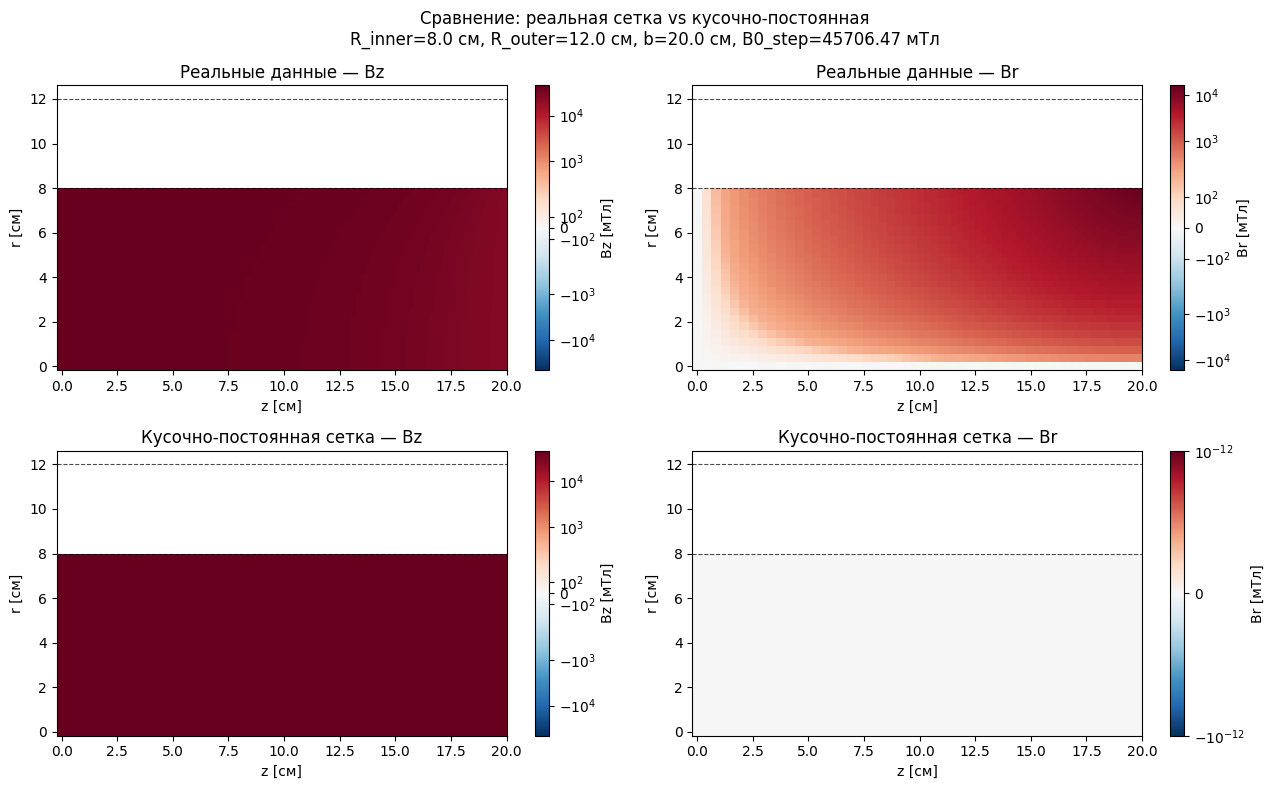

FNTFieldGrid создана:
  Nr = 150,  Nz_half = 150
  r  ∈ [0.0000, 0.0800] м
  z  ∈ [0, 0.2000] м  (половинная)
  beta_r  = 6.7902,  alpha_z = 3.1477
  Bz_max  = 45706.47 мТл
  Br_max  = 0.00 мТл


In [10]:
# @title простая сетка
# =============================================================================
# ВСТАВИТЬ ПОСЛЕ создания fnt_grid (после fnt_grid.plot() в Блоке VI)
#
# Кусочно-постоянная «идеальная» сетка для самопроверки
#
# Физика:
#   Bz_half_simple[ir, iz] = B0_step    если   r[ir] ≤ R_inner < R_outer
#                           = 0          иначе
#   Br_half_simple          = 0          всюду  (идеальный соленоид без краёв)
#
# Форма массивов совпадает с реальными: (Nr, Nz_half).
# Параметры растяжки beta_r, alpha_z берём те же, что у fnt_grid,
# поэтому массивы можно напрямую подставить вместо fnt_grid._Bz_half / _Br_half
# без каких-либо изменений в DimensionlessGridAdapter и CUDA-ядре.
# =============================================================================

import numpy as np

# ── 1. Взять оси из уже построенного fnt_grid (уже в СИ, [м]) ────────────────

r_axis   = fnt_grid._r_grid   # (Nr,)    float32, [м]
z_axis   = fnt_grid._z_half   # (Nz_h,)  float32, [м]
Nr_s     = fnt_grid._Nr
Nz_h_s   = fnt_grid._Nz_h

# ── 2. Геометрия соленоида (из Блока 0) ──────────────────────────────────────

R_inner_s = R - a    # 0.08 м
R_outer_s = R + a    # 0.12 м
# b — полудлина соленоида; z_axis[-1] == b (вся половинная сетка ≤ b)

# ── 3. Характерное поле — пик осевого поля из реальных данных ─────────────────
#
# Используем максимум из загруженных данных, чтобы масштаб совпадал.
# Можно заменить на аналитическое:
#   B0_step = MU0 * J_SI * a * np.log((R_outer_s + np.sqrt(R_outer_s**2 + b**2))
#                                    /(R_inner_s + np.sqrt(R_inner_s**2 + b**2)))

B0_step = float(np.max(np.abs(fnt_grid._Bz_half)))   # [Тл]
print(f"B0_step = {B0_step*1e3:.3f} мТл  ← пик Bz из реальных данных")

# Физически верная маска:
#   r < R_inner  → внутри канала → Bz = B0
#   r ≥ R_inner  → в металле обмотки или снаружи → частица туда не попадает
#                  но для сетки ставим 0

inside_bore = r_axis < R_inner_s    # (Nr,)

Br_half_simple = np.zeros((Nr_s, Nz_h_s), dtype=np.float32)
Bz_half_simple = np.zeros((Nr_s, Nz_h_s), dtype=np.float32)
Bz_half_simple[inside_bore, :] = B0_step

print(f"Узлов внутри борна (r < {R_inner_s*1e2:.1f} см): {inside_bore.sum()} из {Nr_s}")
print(f"Bz_half_simple.max() = {Bz_half_simple.max()*1e3:.3f} мТл  (ожидается {B0_step*1e3:.3f})")

# ── 6. Быстрая проверка: распечатать срезы ────────────────────────────────────

print("\nBz_half_simple — срез по r при iz=0 (z=0):")
print(f"  r[0]   = {r_axis[0]*1e2:.2f} см  →  Bz = {Bz_half_simple[0, 0]*1e3:.2f} мТл")
r_mid = np.argmin(np.abs(r_axis - (R_inner_s + R_outer_s) / 2))
print(f"  r_mid  = {r_axis[r_mid]*1e2:.2f} см  →  Bz = {Bz_half_simple[r_mid, 0]*1e3:.2f} мТл  (ожидается {B0_step*1e3:.2f})")
print(f"  r[-1]  = {r_axis[-1]*1e2:.2f} см  →  Bz = {Bz_half_simple[-1, 0]*1e3:.2f} мТл")

print("\nBz_half_simple — срез по z при r_mid:")
print(f"  z=0    : {Bz_half_simple[r_mid,  0]*1e3:.2f} мТл")
print(f"  z=b/2  : {Bz_half_simple[r_mid, Nz_h_s//2]*1e3:.2f} мТл")
print(f"  z=b    : {Bz_half_simple[r_mid, -1]*1e3:.2f} мТл")

# ── 7. Визуализация для сравнения с реальными данными ─────────────────────────

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

r_cm = r_axis * 1e2
z_cm = z_axis * 1e2
Z_, R_ = np.meshgrid(z_cm, r_cm)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

pairs = [
    (fnt_grid._Bz_half * 1e3, fnt_grid._Br_half * 1e3,  "Реальные данные"),
    (Bz_half_simple    * 1e3, Br_half_simple    * 1e3,  "Кусочно-постоянная сетка"),
]

for row, (Bz_plot, Br_plot, title_row) in enumerate(pairs):
    for col, (field, comp) in enumerate([(Bz_plot, "Bz"), (Br_plot, "Br")]):
        ax = axes[row, col]
        vmax = max(np.max(np.abs(field)), 1e-12)
        norm = SymLogNorm(linthresh=0.01 * vmax + 1e-10, vmin=-vmax, vmax=vmax)
        cf = ax.pcolormesh(Z_, R_, field, cmap='RdBu_r', norm=norm, shading='auto')
        plt.colorbar(cf, ax=ax, label=f"{comp} [мТл]")
        ax.set_xlabel("z [см]")
        ax.set_ylabel("r [см]")
        ax.set_title(f"{title_row} — {comp}")
        # Нанести границы соленоида
        ax.axhline(R_inner_s * 1e2, color='k', ls='--', lw=0.8, alpha=0.7, label='R_inner/R_outer')
        ax.axhline(R_outer_s * 1e2, color='k', ls='--', lw=0.8, alpha=0.7)

plt.suptitle(
    f"Сравнение: реальная сетка vs кусочно-постоянная\n"
    f"R_inner={R_inner_s*1e2:.1f} см, R_outer={R_outer_s*1e2:.1f} см, "
    f"b={b*1e2:.1f} см, B0_step={B0_step*1e3:.2f} мТл",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# ── 8. Использование вместо реальной сетки ────────────────────────────────────
#
# Чтобы запустить трекер с кусочно-постоянным полем, достаточно:
#
fnt_grid_simple = FNTFieldGrid(
       r_grid  = r_axis,
       z_half  = z_axis,
       Br_half = Br_half_simple,
       Bz_half = Bz_half_simple,
       beta_r  = beta_fnt,
       alpha_z = alpha_fnt,
)
# adapted_simple = DimensionlessGridAdapter(fnt_grid_simple, scaling, solenoids=solenoids)
#
# Далее передать adapted_simple в BeamTracerCUDA вместо adapted.
# Все остальные параметры без изменений.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Загружено:
  r_grid  : (150,),  [0.0000, 0.0800] м
  z_half  : (150,),  [0.0000, 0.2000] м
  Br_half : (150, 150),  max = 16532.57 мТл
  Bz_half : (150, 150),  max = 45706.47 мТл
FNTFieldGrid создана:
  Nr = 150,  Nz_half = 150
  r  ∈ [0.0000, 0.0800] м
  z  ∈ [0, 0.2000] м  (половинная)
  beta_r  = 6.7902,  alpha_z = 3.1477
  Bz_max  = 45706.47 мТл
  Br_max  = 16532.57 мТл
Тест 1  Br(r=0):   max|Br_axis| / max|Br| = 7.76e-16  ✓
Тест 2  Br(z=0):   max|Br_z0|  / max|Br| = 0.00e+00  ✓
Тест 3  ∇·B=0:     max|∇·B| / max|Bz|    = 9.78e+00  ✗  ОШИБКА
  Есть нарушения — проверьте исходные данные.
ScalingTransform создан:
  γ₀   = 6850.329143
  L0   = 1.000e-01 м
  P0   = 1.871e-18 кг·м/с
  T0   = 3.336e-10 с  (0.3336 нс)
  B0   = 1.168e+02 Тл
Физический шаг   dt  = 10.0000 пс
Безразмерный шаг dt̃  = 2.9979e-02


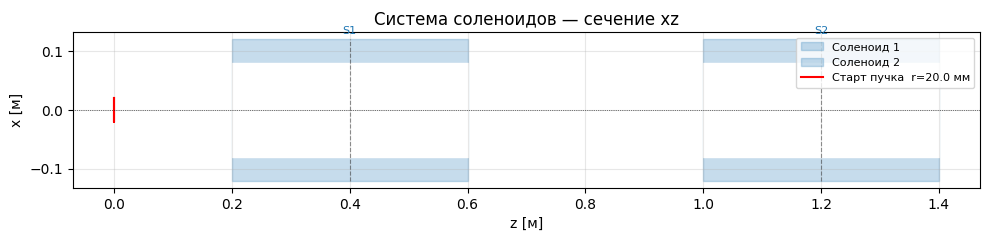

p̃_z (безразм.)   = 1.000000  (должно быть ≈ 1.0)
p_z (физ.)        = 1.8708e-18 кг·м/с
Поперечный импульс ≤ 1.0% от p_z
⟨x₀⟩ = 0.000 мм,  σ_x = 1.000 мм
DimensionlessGridAdapter (FNT):
  r̃ ∈ [0.000, 0.800]
  z̃_half ∈ [0, 2.000]
  B0 = 1.168e+02 Тл
  Соленоиды ẑ_c = [ 4. 12.]
История: 51 кадров  (каждый 20-й шаг из 1000)  ≈ 1224.0 МБ RAM


Трекировка:   0%|          | 0/1000 [00:00<?, ?шаг/s]


── Время выполнения: 152.900 с ──

x_hist : (51, 1000000, 3)  [м]
p_hist : (51, 1000000, 3)  [кг·м/с]
t_hist : (51,)  [с],  t_max = 10.00 нс
Шагов записано  : 1000
γ₀ (теория)     = 6850.329143
⟨γ⟩ финальное   = 6850.557016  (Δγ/γ₀ = 3.33e-05)
⟨|B|⟩ финальное = 0.000 мТл
⟨|F̃|⟩ финальное = 0.000e+00


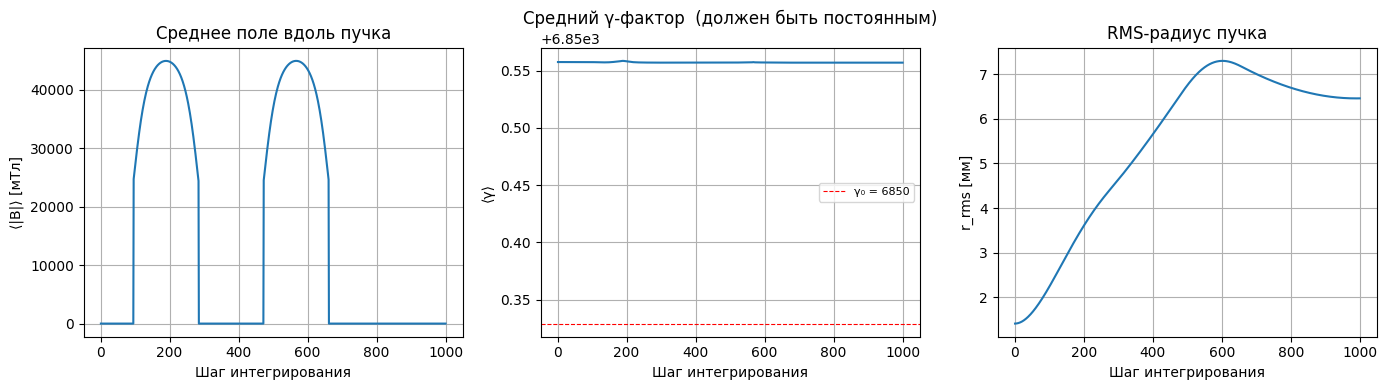

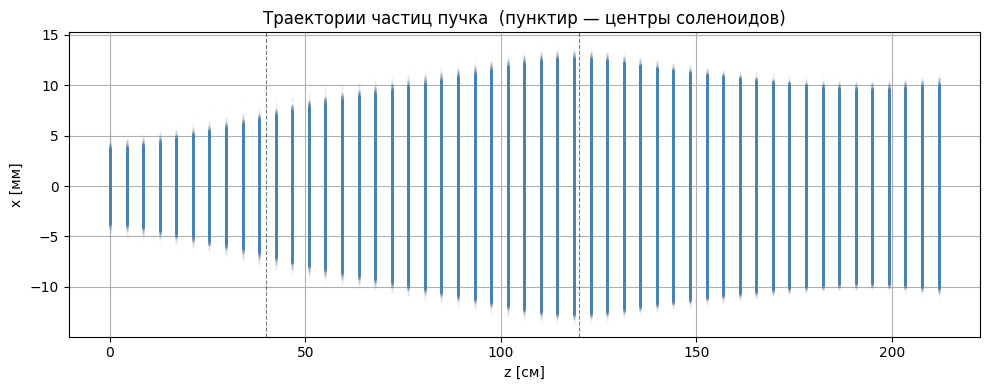

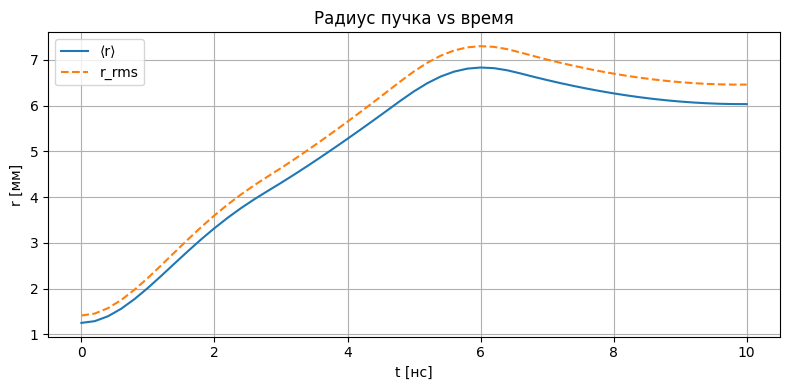

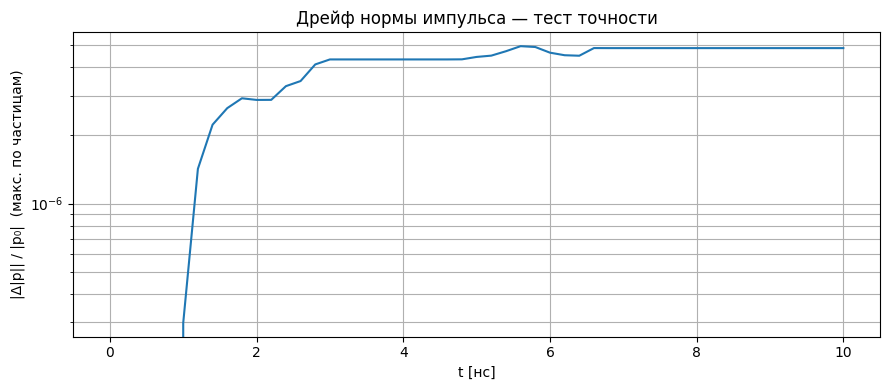

Максимальный дрейф |p| за всё время: 4.96e-06
Финальный дрейф  |p|:                4.86e-06


In [11]:
# ============================================================
# БЛОК VI — Загрузка данных, инициализация и запуск
# ============================================================


# ── Ячейка 0: монтирование Drive и загрузка FNT-файла ────────────────────────

from google.colab import drive
drive.mount('/content/drive')

ALPHA_FNT = 3.1477
BETA_FNT  = 6.7902

FNT_PATH = '/content/drive/MyDrive/КУРСОВАЯ РАБОТА/FNT_half_grid_data(150x150_Z+).npy'

fnt_data                   = np.load(FNT_PATH, allow_pickle=True)
spf_grid, Br_half, Bz_half = fnt_data[0]
r_grid_fnt, z_half_fnt     = spf_grid

r_grid_fnt = r_grid_fnt * 1e-2
z_half_fnt = z_half_fnt * 1e-2

print(f"Загружено:")
print(f"  r_grid  : {r_grid_fnt.shape},  [{r_grid_fnt[0]:.4f}, {r_grid_fnt[-1]:.4f}] м")
print(f"  z_half  : {z_half_fnt.shape},  [{z_half_fnt[0]:.4f}, {z_half_fnt[-1]:.4f}] м")
print(f"  Br_half : {Br_half.shape},  max = {np.max(np.abs(Br_half))*1e3:.2f} мТл")
print(f"  Bz_half : {Bz_half.shape},  max = {np.max(np.abs(Bz_half))*1e3:.2f} мТл")


# ── Ячейка 1: FNTFieldGrid + валидация ───────────────────────────────────────

fnt_grid = FNTFieldGrid(
    r_grid  = r_grid_fnt,
    z_half  = z_half_fnt,
    Br_half = Br_half,
    Bz_half = Bz_half,
    beta_r  = BETA_FNT,
    alpha_z = ALPHA_FNT,
)

fnt_grid.check_symmetry()
# fnt_grid.plot()


# ── Ячейка 2: физические параметры ───────────────────────────────────────────

beam_phys = BeamPhysicalParams(
    mass           = m_e,
    charge         = -e_charge,
    c              = c_light,
    kinetic_energy = 3.5e9 * eV,
)

scaling = ScalingTransform.from_physical_problem(
    phys = beam_phys,
    L0   = 0.1,
)

# T0 выводится в from_physical_problem — используем его для выбора t_end.
# При T0 ≈ 0.334 нс и t_end=15 нс получаем ~44.9 безразмерных единиц времени.
# dt̃ = (t_end - t_start) / (n_steps · T0) вычисляется автоматически в run().

beam_num = BeamNumericalParams(
    t_start           = 0.0,      # [с]
    t_end             = 10e-9,    # [с]  ≈ 45 · T0
    n_steps           = 1000,
    threads_per_block = 128,      # было 256 → 20 блоков; теперь 128 → 40 блоков
)

# Информация о шаге
dt_phys   = (beam_num.t_end - beam_num.t_start) / beam_num.n_steps
dt_dimless = dt_phys / scaling.T0
print(f"Физический шаг   dt  = {dt_phys*1e12:.4f} пс")
print(f"Безразмерный шаг dt̃  = {dt_dimless:.4e}")

z1 = 0.40
z2 = 1.20
solenoids = [
    SolenoidParams(center=np.array([0.0, 0.0, z1]),
                   const=1.0, length=2*b, R_inner=R-a, R_outer=R+a),
    SolenoidParams(center=np.array([0.0, 0.0, z2]),
                   const=1.0, length=2*b, R_inner=R-a, R_outer=R+a),
]

plot_solenoid_system(solenoids, z_start=0.0, r_beam=2e-2)


# ── Ячейка 3: начальные условия ──────────────────────────────────────────────

N_PARTICLES = 1_000_000
STRIDE      = 20

rng = np.random.default_rng(seed=42)

x0 = np.zeros((N_PARTICLES, 3), dtype=np.float32)
x0[:, 0] = rng.normal(0.0, 1e-3, N_PARTICLES)
x0[:, 1] = rng.normal(0.0, 1e-3, N_PARTICLES)

# energy_to_momentum возвращает p̃ = p/P0 (безразм.) —
# умножаем на P0 чтобы получить физический импульс [кг·м/с] для run()
p_z_dimless = scaling.energy_to_momentum(beam_phys.kinetic_energy)
p_z_phys    = p_z_dimless * scaling.P0

p0 = np.zeros((N_PARTICLES, 3), dtype=np.float32)
p0[:, 2] = p_z_phys

frac = 0.01
p0[:, 0] = p_z_phys * rng.uniform(-frac, frac, N_PARTICLES)
p0[:, 1] = p_z_phys * rng.uniform(-frac, frac, N_PARTICLES)

print(f"p̃_z (безразм.)   = {p_z_dimless:.6f}  (должно быть ≈ 1.0)")
print(f"p_z (физ.)        = {p_z_phys:.4e} кг·м/с")
print(f"Поперечный импульс ≤ {frac*100:.1f}% от p_z")
print(f"⟨x₀⟩ = {x0[:,0].mean()*1e3:.3f} мм,  σ_x = {x0[:,0].std()*1e3:.3f} мм")


# ── Ячейка 4: адаптер + трекировщик + запуск ─────────────────────────────────

adapted = DimensionlessGridAdapter(fnt_grid, scaling, solenoids=solenoids)

diagnostics = BeamDiagnostics()

tracer = BeamTracerCUDA(
    adapted_grid = adapted,
    phys         = beam_phys,
    num          = beam_num,
    scaling      = scaling,
    diagnostics  = diagnostics,
)

x_hist, p_hist, t_hist = tracer.run(
    x0, p0,
    store_history = True,
    stride        = STRIDE,
)

print(f"\nx_hist : {x_hist.shape}  [м]")
print(f"p_hist : {p_hist.shape}  [кг·м/с]")
print(f"t_hist : {t_hist.shape}  [с],  t_max = {t_hist[-1]*1e9:.2f} нс")


# ── Ячейка 5: диагностика пучка ──────────────────────────────────────────────

gamma0_ref = 1.0 + beam_phys.kinetic_energy / (m_e * c_light**2)

print(f"Шагов записано  : {len(diagnostics.steps)}")
print(f"γ₀ (теория)     = {gamma0_ref:.6f}")
print(f"⟨γ⟩ финальное   = {diagnostics.mean_gamma[-1]:.6f}  "
      f"(Δγ/γ₀ = {abs(diagnostics.mean_gamma[-1] - gamma0_ref)/gamma0_ref:.2e})")
print(f"⟨|B|⟩ финальное = {diagnostics.mean_B[-1]*1e3:.3f} мТл")
print(f"⟨|F̃|⟩ финальное = {diagnostics.mean_F[-1]:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(diagnostics.steps, np.array(diagnostics.mean_B) * 1e3)
axes[0].set_xlabel("Шаг интегрирования")
axes[0].set_ylabel("⟨|B|⟩ [мТл]")
axes[0].set_title("Среднее поле вдоль пучка")
axes[0].grid(True)

axes[1].plot(diagnostics.steps, diagnostics.mean_gamma)
axes[1].axhline(gamma0_ref, color='r', linestyle='--',
                linewidth=0.8, label=f'γ₀ = {gamma0_ref:.0f}')
axes[1].set_xlabel("Шаг интегрирования")
axes[1].set_ylabel("⟨γ⟩")
axes[1].set_title("Средний γ-фактор  (должен быть постоянным)")
axes[1].legend(fontsize=8)
axes[1].grid(True)

axes[2].plot(diagnostics.steps, np.array(diagnostics.rms_r) * 1e3)
axes[2].set_xlabel("Шаг интегрирования")
axes[2].set_ylabel("r_rms [мм]")
axes[2].set_title("RMS-радиус пучка")
axes[2].grid(True)

plt.tight_layout()
plt.show()


# ── Ячейка 6: траектории в плоскости (z, x) ──────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    x_hist[:, :, 2].reshape(-1) * 1e2,
    x_hist[:, :, 0].reshape(-1) * 1e3,
    '.', alpha=0.03, markersize=1, color='steelblue',
)
for sol in solenoids:
    ax.axvline(sol.center[2] * 1e2, color='k', linestyle='--',
               linewidth=0.8, alpha=0.5)
ax.set_xlabel("z [см]")
ax.set_ylabel("x [мм]")
ax.set_title("Траектории частиц пучка  (пунктир — центры соленоидов)")
ax.grid(True)
plt.tight_layout()
plt.show()


# ── Ячейка 7: средний и RMS-радиус пучка vs время ────────────────────────────

r_hist      = np.sqrt(x_hist[:, :, 0]**2 + x_hist[:, :, 1]**2)
r_mean_hist = r_hist.mean(axis=1)
r_rms_hist  = np.sqrt(np.mean(r_hist**2, axis=1))
t_ns        = t_hist * 1e9

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_ns, r_mean_hist * 1e3, label='⟨r⟩')
ax.plot(t_ns, r_rms_hist  * 1e3, label='r_rms', linestyle='--')
ax.set_xlabel("t [нс]")
ax.set_ylabel("r [мм]")
ax.set_title("Радиус пучка vs время")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


# ── Ячейка 8: тест точности — дрейф нормы импульса ───────────────────────────

p_norm     = np.linalg.norm(p_hist, axis=2)
p_norm_rel = p_norm / p_norm[0, :]
drift      = np.abs(p_norm_rel - 1.0).max(axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_ns, drift)
ax.set_xlabel("t [нс]")
ax.set_ylabel("|Δ|p|| / |p₀|  (макс. по частицам)")
ax.set_title("Дрейф нормы импульса — тест точности")
ax.grid(True, which='both')
plt.tight_layout()
plt.show()

print(f"Максимальный дрейф |p| за всё время: {drift.max():.2e}")
print(f"Финальный дрейф  |p|:                {drift[-1]:.2e}")

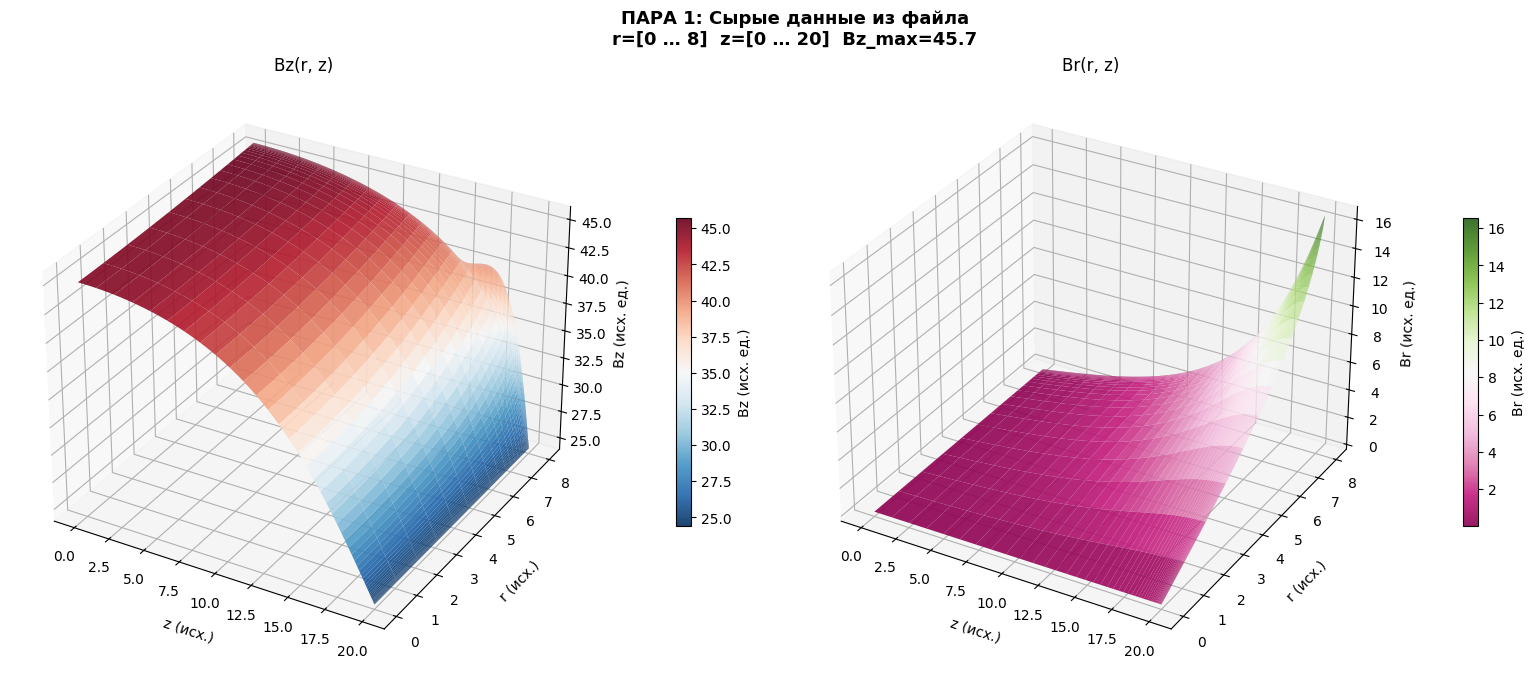

FNTFieldGrid создана:
  Nr = 150,  Nz_half = 150
  r  ∈ [0.0000, 0.0800] м
  z  ∈ [0, 0.2000] м  (половинная)
  beta_r  = 6.7902,  alpha_z = 3.1477
  Bz_max  = 4.57 мТл
  Br_max  = 1.65 мТл
DimensionlessGridAdapter (FNT):
  r̃ ∈ [0.000, 0.800]
  z̃_half ∈ [0, 2.000]
  B0 = 1.168e+02 Тл
  Соленоиды ẑ_c = [ 4. 12.]


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 47 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


B0        = 1.1676e+02 Тл
Bz_max    = 6.931 мТл
Br_max    = 1.524 мТл


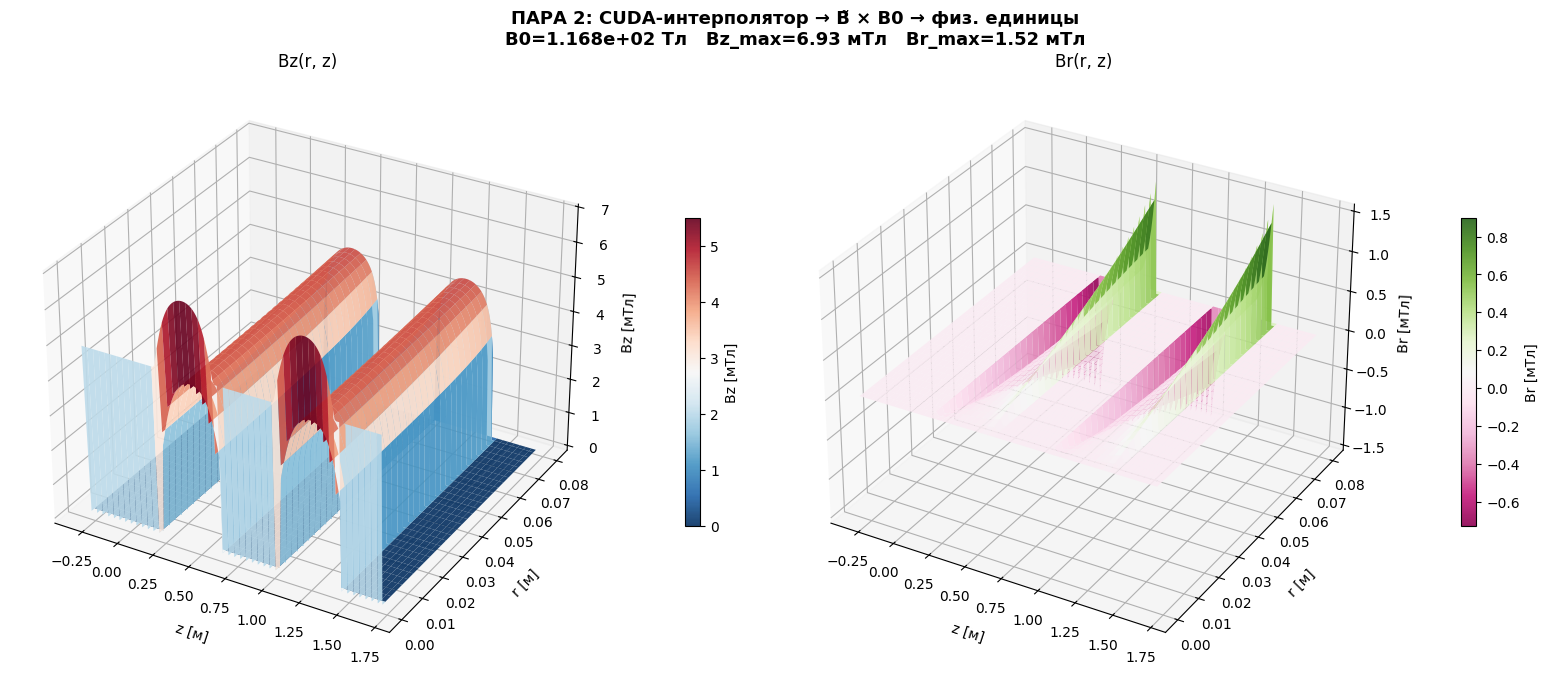

In [12]:
# @title Проверка коректности поля
# =============================================================================
# ДВЕ ПАРЫ 3D ГРАФИКОВ
#   Пара 1: сырые данные из файла
#   Пара 2: через CUDA-интерполятор → обезразмеривание → восстановление
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from numba import cuda
import math


def plot_3d_pair(r_axis, z_axis, Bz, Br, title, r_label="r", z_label="z", b_label=""):
    R_m, Z_m = np.meshgrid(r_axis, z_axis, indexing='ij')

    fig = plt.figure(figsize=(16, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    surf1 = ax1.plot_surface(Z_m, R_m, Bz, cmap='RdBu_r',
                              linewidth=0, antialiased=True, alpha=0.9)
    fig.colorbar(surf1, ax=ax1, shrink=0.5, pad=0.1, label=f"Bz {b_label}")
    ax1.set_xlabel(z_label, labelpad=8)
    ax1.set_ylabel(r_label, labelpad=8)
    ax1.set_zlabel(f"Bz {b_label}")
    ax1.set_title("Bz(r, z)")
    ax1.view_init(elev=30, azim=-60)

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    surf2 = ax2.plot_surface(Z_m, R_m, Br, cmap='PiYG',
                              linewidth=0, antialiased=True, alpha=0.9)
    fig.colorbar(surf2, ax=ax2, shrink=0.5, pad=0.1, label=f"Br {b_label}")
    ax2.set_xlabel(z_label, labelpad=8)
    ax2.set_ylabel(r_label, labelpad=8)
    ax2.set_zlabel(f"Br {b_label}")
    ax2.set_title("Br(r, z)")
    ax2.view_init(elev=30, azim=-60)

    plt.tight_layout()
    plt.show()


# =============================================================================
# ПАРА 1 — Сырые данные из файла
# =============================================================================

fnt_data = np.load(fnt_path, allow_pickle=True)
spf_grid_raw, Br_raw, Bz_raw = fnt_data[0]
r_raw = np.asarray(spf_grid_raw[0], dtype=np.float64)
z_raw = np.asarray(spf_grid_raw[1], dtype=np.float64)
Br_raw = np.asarray(Br_raw, dtype=np.float64)
Bz_raw = np.asarray(Bz_raw, dtype=np.float64)

plot_3d_pair(
    r_raw, z_raw, Bz_raw, Br_raw,
    title=(f"ПАРА 1: Сырые данные из файла\n"
           f"r=[{r_raw.min():.3g} … {r_raw.max():.3g}]  "
           f"z=[{z_raw.min():.3g} … {z_raw.max():.3g}]  "
           f"Bz_max={Bz_raw.max():.3g}"),
    r_label="r (исх.)", z_label="z (исх.)", b_label="(исх. ед.)"
)


# =============================================================================
# ПАРА 2 — Через CUDA-интерполятор
#
# Шаги:
#   1. Нормируем данные (СГС→СИ), создаём FNTFieldGrid + DimensionlessGridAdapter
#   2. Запускаем мини-ядро на тестовой сетке точек (r, z)
#   3. Восстанавливаем размерность: умножаем на B0
# =============================================================================

# ── Нормировка ───────────────────────────────────────────────────────────────
r_SI  = r_raw  * 1e-2    # см → м
z_SI  = z_raw  * 1e-2    # см → м
Br_SI = Br_raw * 1e-4    # Гс → Тл
Bz_SI = Bz_raw * 1e-4    # Гс → Тл

# ── FNTFieldGrid + адаптер ───────────────────────────────────────────────────
fnt_grid = FNTFieldGrid(
    r_grid=r_SI, z_half=z_SI,
    Br_half=Br_SI, Bz_half=Bz_SI,
    beta_r=beta_fnt, alpha_z=alpha_fnt,
)
adapted = DimensionlessGridAdapter(fnt_grid, scaling, solenoids=solenoids)

# ── Тестовая сетка (физические единицы, полная ось z) ────────────────────────
N_r = 60
N_z = 200

r_test_phys = np.linspace(0.0,  r_SI[-1], N_r).astype(np.float32)
z_test_phys = np.linspace(-0.3, 1.7,      N_z).astype(np.float32)

R_m, Z_m = np.meshgrid(r_test_phys, z_test_phys, indexing='ij')

# ── Переводим тестовые точки в безразмерные координаты ───────────────────────
L0 = scaling.L0
r_dimless = (R_m.ravel() / L0).astype(np.float32)
z_dimless = (Z_m.ravel() / L0).astype(np.float32)

# ── Мини-ядро: вычисляет B̃r и B̃z в произвольном наборе точек ───────────────
@cuda.jit
def eval_field_kernel(r_arr, z_arr,
                      Br_grid, Bz_grid,
                      sol_centers,
                      r_min, r_max, z_max_half,
                      beta_r, alpha_z,
                      Nr, Nz_half,
                      Br_out, Bz_out):
    i = cuda.grid(1)
    if i >= r_arr.shape[0]:
        return

    Br_total = 0.0
    Bz_total = 0.0

    for k in range(sol_centers.shape[0]):
        dz = z_arr[i] - sol_centers[k]
        Br_k, Bz_k = _field_one_solenoid(
            Br_grid, Bz_grid,
            r_arr[i], dz,
            r_min, r_max, z_max_half,
            beta_r, alpha_z,
            Nr, Nz_half,
        )
        Br_total += Br_k
        Bz_total += Bz_k

    Br_out[i] = Br_total
    Bz_out[i] = Bz_total


# ── Запуск ───────────────────────────────────────────────────────────────────
N_pts   = len(r_dimless)
threads = 256
blocks  = (N_pts + threads - 1) // threads

Br_d_out = cuda.device_array(N_pts, dtype=np.float32)
Bz_d_out = cuda.device_array(N_pts, dtype=np.float32)

eval_field_kernel[blocks, threads](
    cuda.to_device(r_dimless),
    cuda.to_device(z_dimless),
    adapted.Br_d, adapted.Bz_d,
    adapted.sol_centers_d,
    adapted.r_min, adapted.r_max, adapted.z_max_half,
    adapted.beta_r, adapted.alpha_z,
    adapted.Nr, adapted.Nz,
    Br_d_out, Bz_d_out,
)

# ── Восстановление размерности: B̃ × B0 [Тл] → [мТл] ────────────────────────
B0 = scaling.B0
Bz_mT = Bz_d_out.copy_to_host().reshape(N_r, N_z) * B0 * 1e3
Br_mT = Br_d_out.copy_to_host().reshape(N_r, N_z) * B0 * 1e3

print(f"B0        = {B0:.4e} Тл")
print(f"Bz_max    = {Bz_mT.max():.3f} мТл")
print(f"Br_max    = {Br_mT.max():.3f} мТл")

plot_3d_pair(
    r_test_phys, z_test_phys, Bz_mT, Br_mT,
    title=(f"ПАРА 2: CUDA-интерполятор → B̃ × B0 → физ. единицы\n"
           f"B0={B0:.3e} Тл   "
           f"Bz_max={Bz_mT.max():.2f} мТл   "
           f"Br_max={Br_mT.max():.2f} мТл"),
    r_label="r [м]", z_label="z [м]", b_label="[мТл]"
)